<a href="https://colab.research.google.com/github/lyntos/Python_MS_Wilmu_02/blob/main/7_Coding_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7 Coding Project


Instructor:| Dr. Sheeba David Mabel

Dataset:| IMDB Movie Reviews
Source:| Kaggle
Notes:| Tasks performed using truncated dataset of 150 (50k available)
Method:| Create a Pandas DataFrame, perform all NLP tasks on DataFrame

## [00] Project Requirements
This project aims to gain hands-on experience with various NLP tasks using Python libraries such as TextBlob, NLTK, Textatistic, and spaCy. Follow all of the steps below and submit your code using a Jupyter Notebook and a Word document with your findings:



### Project Components
* **01. Data Collection**:
  * Collect a dataset suitable for NLP tasks.
  * This could be a collection of tweets, movie reviews, news articles, etc.

* **02. Data Preprocessing**:
  * Clean and preprocess the data
  * This includes tasks like:
    * tokenizing the text into words and sentences
    * removing stop words
    * getting word roots via stemming and lemmatization

* **03. Parts-of-Speech Tagging**:
  * Use parts-of-speech tagging to understand the grammatical structure of the sentences in your dataset.

* **04. Sentiment Analysis**:
  * Use sentiment analysis to determine whether the text is positive, negative, or neutral.
  * Discuss how this information can be useful in understanding the dataset.

* **05. Language Detection and Translation**:
  * Detect the language of the text and translate it into English using TextBlob’s Google Translate support.

* **06. Spell Checking and Correction**:
  * Use TextBlob’s spell-checking and correction capabilities to correct any spelling mistakes in the dataset.

* **07. Word Definitions, Synonyms, and Antonyms**:
  * For a selected list of words in your dataset, get their:
    * definitions
    * synonyms
    * antonyms

* **08. Word Clouds**:
  * Create word clouds to visualize the most common words in your dataset.

* **9. Named Entity Recognition and Similarity Detection**:
  * Use the spaCy library for:
    * named entity recognition
    * similarity detection

* **10. Text Readability**: Determine the readability of the text in your dataset using Textatistic

* **11. Conclusion**:
  * Write a conclusion:
    * summarizing your findings
    * discussing the strengths and weaknesses of the different NLP tasks
    * suggesting possible improvements or future work

### **01. Data Collection**:
  1. Collect a dataset suitable for NLP tasks.
  2. This could be a collection of tweets, movie reviews, news articles, etc.

In [ ]:
# import kaggle dataset
import kagglehub
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

# get the downloaded file
kaggle_file = '/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv'


Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.


In [ ]:
import os
import pathlib
# write the dataset from path to a csv
with open(kaggle_file, 'r') as file:
  file_idmb_writer = open('imdb_dataset.csv', 'w')
  file_idmb_writer.write(file.read())
  file_idmb_writer.close()
  file.close()
  print('File written')
# get the filepath of file_imdb
file_imdb = pathlib.Path('imdb_dataset.csv')

File written


In [ ]:
# truncate the dataset for development and debugging
import pandas as pd

try:
  kaggle_truncated_df = pd.read_csv(file_imdb, nrows=150)
  kaggle_full_df = pd.read_csv(file_imdb)
  print('DataFrames created')
except Exception as e:
  print(e)
  print('DataFrames not created')


DataFrames created


In [ ]:
# prove the data was written using pandas
kaggle_truncated_df.info()
print()
kaggle_full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     150 non-null    object
 1   sentiment  150 non-null    object
dtypes: object(2)
memory usage: 2.5+ KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


### **02. Data Preprocessing**:
  01. Clean and preprocess the data
  02. This includes tasks like:
>
    01. tokenizing the text into words and sentences
    02. removing stop words
    03. getting word roots via stemming and lemmatization



In [ ]:
# import libraries for preprocessing
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.tokenize import word_tokenize
import spacy

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nlp = spacy.load('en_core_web_sm')
nltk.download('stopwords')

In [ ]:
kaggle_truncated_df.head()

In [ ]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

In [ ]:
# clean the data in the kaggle_truncated_df
# lowercase
kaggle_truncated_df['review'] = kaggle_truncated_df['review'].str.lower()
# remove punctuation with re
kaggle_truncated_df['review'] = kaggle_truncated_df['review'].str.replace(r'[^\w\s]', '', regex=True)
# strip
kaggle_truncated_df['review'] = kaggle_truncated_df['review'].str.strip()

In [ ]:
# remove stop words
stop_words = set(stopwords.words('english'))
kaggle_truncated_df['review_stops_removed'] = kaggle_truncated_df['review'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop_words)]))

In [ ]:
# get tokenized words, sentences, stem, lemmatize

# create a new df column with tokenized words
kaggle_truncated_df['word_tokens'] = kaggle_truncated_df['review'].apply(lambda x: word_tokenize(x))

# create column of tokenized sentences
kaggle_truncated_df['sentence_tokens'] = kaggle_truncated_df['review'].apply(lambda x: sent_tokenize(x))

# stem words
kaggle_truncated_df['stemmed'] = kaggle_truncated_df['word_tokens'].apply(
    lambda tokens: [stemmer.stem(w) for w in tokens]
)

# lem words using nlp.pipe
kaggle_truncated_df['lemmatized'] = [
    [token.lemma_ for token in doc]
    for doc in nlp.pipe(kaggle_truncated_df['review'])
]

In [ ]:
# Words to preserve for sentiment analysis
preserve = {
    "no", "not", "nor", "never", "neither", "none", "nobody", "nothing", "nowhere",  # negations
    "very", "really", "extremely", "incredibly", "absolutely", "too", "so", # intensifiers
    "barely", "hardly", "scarcely", "almost", "nearly" # downtoners
}

stop_words -= preserve

kaggle_truncated_df['review_stops_preserved'] = kaggle_truncated_df['review'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop_words)]))

kaggle_truncated_df['lemmatized_clean'] = kaggle_truncated_df['lemmatized'].apply(
    lambda tokens: [t for t in tokens if t.lower() not in stop_words] if isinstance(tokens, list) else []
)

In [ ]:
# show preprocessing complete
kaggle_truncated_df.head()

### **03. Parts-of-Speech Tagging**:
  01. Use parts-of-speech tagging to understand the grammatical structure of the sentences in your dataset.



In [ ]:
kaggle_truncated_df['pos_tags'] = [
    [(token.text, token.pos_) for token in doc]
    for doc in nlp.pipe(kaggle_truncated_df['review_stops_preserved'])
]

### **04. Sentiment Analysis**:
  01. Use sentiment analysis to determine whether the text is positive, negative, or neutral.
  02. Discuss how this information can be useful in understanding the dataset.


In [ ]:
from textblob import TextBlob

def label_sentiment(score):
    if score > 0.1:
        return 'positive'
    elif score < -0.1:
        return 'negative'
    else:
        return 'neutral'

kaggle_truncated_df['sentiment_tb'] = kaggle_truncated_df['review_stops_preserved'].apply(lambda x: TextBlob(x).sentiment)
kaggle_truncated_df['polarity'] = kaggle_truncated_df['review_stops_preserved'].apply(lambda x: TextBlob(x).sentiment.polarity)
kaggle_truncated_df['subjectivity'] = kaggle_truncated_df['review_stops_preserved'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

kaggle_truncated_df['sentiment_label'] = kaggle_truncated_df['polarity'].apply(label_sentiment)

In [ ]:
kaggle_truncated_df.head()

### **05. Language Detection and Translation**:
  01. Detect the language of the text and translate it into English using TextBlob’s Google Translate support.


In [ ]:
!pip install langdetect deep-translator

In [ ]:
from textblob import TextBlob # no longer uses google translate
from langdetect import detect
from deep_translator import GoogleTranslator

In [ ]:
def detect_and_translate_tamil(text):
    try:
        lang = detect(text)
        if lang != 'ta':
            translation = GoogleTranslator(source='auto', target='ta').translate(text)
        else:
            translation = text  # already Tamil, skip API call
        return lang, 'ta', translation
    except:
        return 'unknown', 'ta', text

kaggle_truncated_df[['original_language', 'target_language', 'translation']] = (
    kaggle_truncated_df['review_stops_preserved']
    .apply(detect_and_translate_tamil)
    .apply(pd.Series)
)

In [ ]:
kaggle_truncated_df.head()

,review,sentiment,review_stops_removed,review_stops_preserved,word_tokens,sentence_tokens,stemmed,lemmatized,lemmatized_clean,sentiment_tb,polarity,subjectivity,sentiment_label,pos_tags,original_language,target_language,translation
0,one of the other reviewers has mentioned that ...,positive,one reviewers mentioned watching 1 oz episode ...,one reviewers mentioned watching 1 oz episode ...,"[one, of, the, other, reviewers, has, mentione...",[one of the other reviewers has mentioned that...,"[one, of, the, other, review, ha, mention, tha...","[one, of, the, other, reviewer, have, mention,...","[one, reviewer, mention, watch, 1, oz, episode...","(0.01701530612244898, 0.498265306122449)",0.017015,0.498265,neutral,"[(one, NUM), (reviewers, NOUN), (mentioned, VE...",en,ta,ஒரு விமர்சகர் 1 அவுன்ஸ் எபிசோடைப் பார்த்ததைக் ...
1,a wonderful little production br br the filmin...,positive,wonderful little production br br filming tech...,wonderful little production br br filming tech...,"[a, wonderful, little, production, br, br, the...",[a wonderful little production br br the filmi...,"[a, wonder, littl, product, br, br, the, film,...","[a, wonderful, little, production, br, br, the...","[wonderful, little, production, br, br, filmin...","(0.13564814814814813, 0.537962962962963)",0.135648,0.537963,positive,"[(wonderful, ADJ), (little, ADJ), (production,...",en,ta,அற்புதமான சிறிய தயாரிப்பு பி.ஆர்.பி.பி.சி. ஃபே...
2,i thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...,thought wonderful way spend time too hot summe...,"[i, thought, this, was, a, wonderful, way, to,...",[i thought this was a wonderful way to spend t...,"[i, thought, thi, wa, a, wonder, way, to, spen...","[I, think, this, be, a, wonderful, way, to, sp...","[think, wonderful, way, spend, time, too, hot,...","(0.26473214285714286, 0.6803571428571429)",0.264732,0.680357,positive,"[(thought, VERB), (wonderful, ADJ), (way, NOUN...",en,ta,கோடை வார இறுதியில் குளிரூட்டப்பட்ட திரையரங்கில...
3,basically theres a family where a little boy j...,negative,basically theres family little boy jake thinks...,basically theres family little boy jake thinks...,"[basically, theres, a, family, where, a, littl...",[basically theres a family where a little boy ...,"[basic, there, a, famili, where, a, littl, boy...","[basically, there, s, a, family, where, a, lit...","[basically, family, little, boy, jake, think, ...","(0.001388888888888884, 0.4592592592592592)",0.001389,0.459259,neutral,"[(basically, ADV), (there, PRON), (s, VERB), (...",en,ta,அடிப்படையில் குடும்பத்தில் குட்டிப் பையன் ஜேக்...
4,petter matteis love in the time of money is a ...,positive,petter matteis love time money visually stunni...,petter matteis love time money visually stunni...,"[petter, matteis, love, in, the, time, of, mon...",[petter matteis love in the time of money is a...,"[petter, mattei, love, in, the, time, of, mone...","[petter, matteis, love, in, the, time, of, mon...","[petter, matteis, love, time, money, visually,...","(0.18397867564534232, 0.41004489337822675)",0.183979,0.410045,positive,"[(petter, NOUN), (matteis, PROPN), (love, PROP...",en,ta,petter matteis காதல் நேரம் பணம் பார்வைக்கு பிர...


### **06. Spell Checking and Correction**:
  01. Use TextBlob’s spell-checking and correction capabilities to correct any spelling mistakes in the dataset.


In [ ]:
def spellcheck(text):
    try:
        return str(TextBlob(text).correct())
    except:
        return text

kaggle_truncated_df['spelling_corrected'] = kaggle_truncated_df['review_stops_preserved'].apply(spellcheck)

In [ ]:
mask = kaggle_truncated_df['review_stops_preserved'] != kaggle_truncated_df['spelling_corrected']
kaggle_truncated_df[mask][['review_stops_preserved', 'spelling_corrected']].head(10)

,review_stops_preserved,spelling_corrected
0,one reviewers mentioned watching 1 oz episode ...,one reviews mentioned watching 1 oz episode yo...
1,wonderful little production br br filming tech...,wonderful little production br br filling tech...
2,thought wonderful way spend time too hot summe...,thought wonderful way spend time too hot summe...
3,basically theres family little boy jake thinks...,basically there family little boy jake thinks ...
4,petter matteis love time money visually stunni...,letter matters love time money usually stunnin...
5,probably alltime favorite movie story selfless...,probably alliee favorite movie story helplessn...
6,sure would like see resurrection dated seahunt...,sure would like see resurrection dated seahunt...
7,show amazing fresh innovative idea 70s first a...,show amazing fresh innovative idea was first t...
8,encouraged positive comments film looking forw...,encouraged positive comments film looking forw...
9,like original gut wrenching laughter like movi...,like original gut wrenching laughter like movi...


### **07. Word Definitions, Synonyms, and Antonyms**:
  01. For a selected list of words in your dataset, get their:
>
    01. definitions
    02. synonyms
    03. antonyms


In [ ]:
from nltk.corpus import wordnet
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
def get_definitions(text):
    return {word: [syn.definition() for syn in wordnet.synsets(word)]
            for word in word_tokenize(text) if wordnet.synsets(word)}

def get_synonyms(text):
    return {word: list({lemma.name() for syn in wordnet.synsets(word)
                        for lemma in syn.lemmas()})
            for word in word_tokenize(text) if wordnet.synsets(word)}

def get_antonyms(text):
    return {word: list({antonym.name() for syn in wordnet.synsets(word)
                        for lemma in syn.lemmas()
                        for antonym in lemma.antonyms()})
            for word in word_tokenize(text) if wordnet.synsets(word)}

word_lookup_df = pd.DataFrame(index=kaggle_truncated_df.index)
word_lookup_df['definitions'] = kaggle_truncated_df['spelling_corrected'].apply(get_definitions)
word_lookup_df['synonyms'] = kaggle_truncated_df['spelling_corrected'].apply(get_synonyms)
word_lookup_df['antonyms'] = kaggle_truncated_df['spelling_corrected'].apply(get_antonyms)

In [ ]:
word_lookup_df.head()

,definitions,synonyms,antonyms
0,{'one': ['the smallest whole number or a numer...,"{'one': ['matchless', 'unmatched', 'ace', 'ane...","{'one': [], 'reviews': [], 'mentioned': [], 'w..."
1,{'wonderful': ['extraordinarily good or great ...,"{'wonderful': ['howling', 'terrific', 'fantast...","{'wonderful': [], 'little': ['large', 'tall', ..."
2,{'thought': ['the content of cognition; the ma...,"{'thought': ['thought', 'believe', 'suppose', ...","{'thought': ['forget'], 'wonderful': [], 'way'..."
3,{'basically': ['in essence; at bottom or by on...,"{'basically': ['fundamentally', 'basically', '...","{'basically': [], 'there': ['here'], 'family':..."
4,{'letter': ['a written message addressed to a ...,"{'letter': ['varsity_letter', 'alphabetic_char...","{'letter': [], 'matters': [], 'love': ['hate']..."


Note: WordNet does not return many antonyms - there is likely a better method for this.

### **08. Word Clouds**:
  01. Create word clouds to visualize the most common words in your dataset.


In [ ]:
!pip install wordcloud

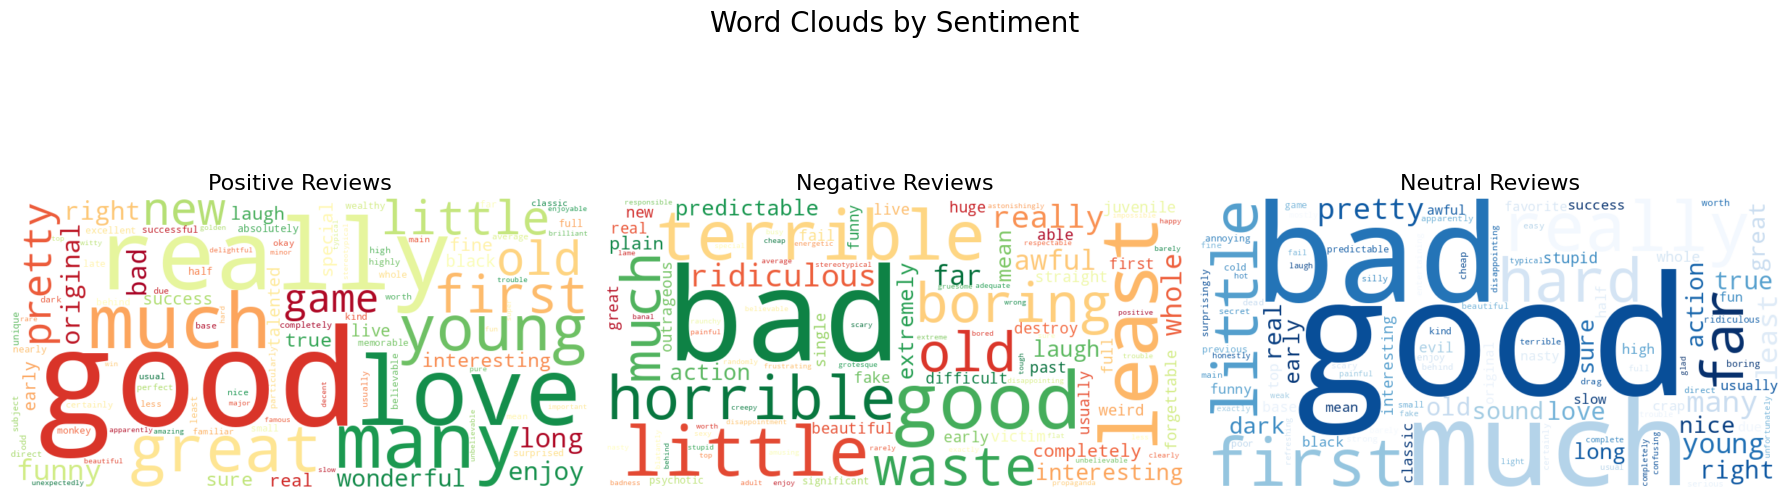

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

from textblob import Word

def is_sentiment_word(word):
    return TextBlob(word).sentiment.polarity != 0.0

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, label in zip(axes, ['positive', 'negative', 'neutral']):
    text = ' '.join(
        word for tokens in kaggle_truncated_df[kaggle_truncated_df['sentiment_label'] == label]['lemmatized_clean']
        for word in tokens
        if is_sentiment_word(word)  # only sentiment-bearing words
    )

    wordcloud = WordCloud(
        width=800, height=400,
        background_color='white',
        max_words=100,
        colormap='RdYlGn' if label == 'positive' else 'RdYlGn_r' if label == 'negative' else 'Blues'
    ).generate(text)

    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(f'{label.capitalize()} Reviews', fontsize=16)
    ax.axis('off')

plt.suptitle('Word Clouds by Sentiment', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

### **9. Named Entity Recognition and Similarity Detection**:
  01. Use the spaCy library for:
>
    01. named entity recognition
    02. similarity detection

In [ ]:
kaggle_truncated_df['named_entities'] = [
    [(ent.text, ent.label_) for ent in doc.ents]
    for doc in nlp.pipe(kaggle_truncated_df['review_stops_preserved'])]

In [ ]:
#similarity detection omitted, although one could probably use this on the 50k dataset to determine non-human reviews

### **10. Text Readability**:
  01. Determine the readability of the text in your dataset using **Textatistic**


In [ ]:
!pip install textatistic

In [ ]:
from textatistic import Textatistic
import re

In [ ]:
def get_textatistic_scores(text):
    try:
        s = Textatistic(text)
        return {
            'flesch_score': s.flesch_score,
            'fleschkincaid_score': s.fleschkincaid_score,
            'gunningfog_score': s.gunningfog_score,
            'smog_score': s.smog_score,
            'dalechall_score': s.dalechall_score
        }
    except:
        return {
            'flesch_score': None,
            'fleschkincaid_score': None,
            'gunningfog_score': None,
            'smog_score': None,
            'dalechall_score': None
        }

def fix_sentences(text):
    # add period at end if missing
    if not text.strip().endswith(('.', '!', '?')):
        text = text.strip() + '.'
    return text




In [ ]:
kaggle_truncated_df['word_count'] = kaggle_truncated_df['review'].apply(lambda x: len(x.split()))
kaggle_truncated_df['sentence_count'] = kaggle_truncated_df['review'].apply(lambda x: len(sent_tokenize(x)))

In [ ]:
kaggle_truncated_df['review_fixed'] = kaggle_truncated_df['review'].apply(fix_sentences)
kaggle_truncated_df['review_stops_preserved_fixed'] = kaggle_truncated_df['review_stops_preserved'].apply(fix_sentences)
kaggle_truncated_df['spelling_corrected_fixed'] = kaggle_truncated_df['spelling_corrected'].apply(fix_sentences)

In [ ]:
scores_raw = kaggle_truncated_df['review_fixed'].apply(get_textatistic_scores).apply(pd.Series)
scores_no_stop = kaggle_truncated_df['review_stops_preserved_fixed'].apply(get_textatistic_scores).apply(pd.Series)
scores_spellchecked = kaggle_truncated_df['spelling_corrected_fixed'].apply(get_textatistic_scores).apply(pd.Series)
kaggle_truncated_df = pd.concat([kaggle_truncated_df, scores_raw], axis=1)
kaggle_truncated_df = pd.concat([kaggle_truncated_df, scores_no_stop], axis=1)
kaggle_truncated_df = pd.concat([kaggle_truncated_df, scores_spellchecked], axis=1)

> after review, I should have created a function for this (and appended the source name to the column name)

In [ ]:
kaggle_truncated_df.head(10)

,review,sentiment,review_stops_removed,review_stops_preserved,word_tokens,sentence_tokens,stemmed,lemmatized,lemmatized_clean,sentiment_tb,...,flesch_score,fleschkincaid_score,gunningfog_score,smog_score,dalechall_score,flesch_score,fleschkincaid_score,gunningfog_score,smog_score,dalechall_score
0,one of the other reviewers has mentioned that ...,positive,one reviewers mentioned watching 1 oz episode ...,one reviewers mentioned watching 1 oz episode ...,"[one, of, the, other, reviewers, has, mentione...",[one of the other reviewers has mentioned that...,"[one, of, the, other, review, ha, mention, tha...","[one, of, the, other, reviewer, have, mention,...","[one, reviewer, mention, watch, 1, oz, episode...","(0.01701530612244898, 0.498265306122449)",...,-96.135254,70.640000,75.093785,28.030384,19.820050,-95.179322,70.506667,74.641808,26.683356,18.838751
1,a wonderful little production br br the filmin...,positive,wonderful little production br br filming tech...,wonderful little production br br filming tech...,"[a, wonderful, little, production, br, br, the...",[a wonderful little production br br the filmi...,"[a, wonder, littl, product, br, br, the, film,...","[a, wonderful, little, production, br, br, the...","[wonderful, little, production, br, br, filmin...","(0.13564814814814813, 0.537962962962963)",...,-40.088947,42.451579,46.421053,28.677278,16.160395,-37.417368,42.078947,45.578947,27.366230,15.994184
2,i thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...,thought wonderful way spend time too hot summe...,"[i, thought, this, was, a, wonderful, way, to,...",[i thought this was a wonderful way to spend t...,"[i, thought, thi, wa, a, wonder, way, to, spen...","[I, think, this, be, a, wonderful, way, to, sp...","[think, wonderful, way, spend, time, too, hot,...","(0.26473214285714286, 0.6803571428571429)",...,-12.894835,37.664835,41.674725,22.918634,15.784825,-9.176154,37.146154,40.795604,21.194390,14.743726
3,basically theres a family where a little boy j...,negative,basically theres family little boy jake thinks...,basically theres family little boy jake thinks...,"[basically, theres, a, family, where, a, littl...",[basically theres a family where a little boy ...,"[basic, there, a, famili, where, a, littl, boy...","[basically, there, s, a, family, where, a, lit...","[basically, family, little, boy, jake, think, ...","(0.001388888888888884, 0.4592592592592592)",...,10.380000,29.698333,31.577778,15.903189,14.664089,6.855000,30.190000,32.133333,17.122413,14.225478
4,petter matteis love in the time of money is a ...,positive,petter matteis love time money visually stunni...,petter matteis love time money visually stunni...,"[petter, matteis, love, in, the, time, of, mon...",[petter matteis love in the time of money is a...,"[petter, mattei, love, in, the, time, of, mone...","[petter, matteis, love, in, the, time, of, mon...","[petter, matteis, love, time, money, visually,...","(0.18397867564534232, 0.41004489337822675)",...,-60.454091,54.483939,58.557576,28.030384,17.121730,-57.890455,54.126364,57.951515,26.683356,16.284382
5,probably my alltime favorite movie a story of ...,positive,probably alltime favorite movie story selfless...,probably alltime favorite movie story selfless...,"[probably, my, alltime, favorite, movie, a, st...",[probably my alltime favorite movie a story of...,"[probabl, my, alltim, favorit, movi, a, stori,...","[probably, my, alltime, favorite, movie, a, st...","[probably, alltime, favorite, movie, story, se...","(0.08333333333333336, 0.5305555555555556)",...,21.855000,25.116667,30.000000,20.267339,12.402167,19.035000,25.510000,30.000000,20.267339,11.349500
6,i sure would like to see a resurrection of a u...,positive,sure would like see resurrection dated seahunt...,sure would like see resurrection dated seahunt...,"[i, sure, would, like, to, see, a, resurrectio...",[i sure would like to see a resurrection of a ...,"[i, sure, would, like, to, see,

### **11. Conclusion**:
  01. Write a conclusion:
>
    01. summarizing your findings
    02. discussing the strengths and weaknesses of the different NLP tasks
    03. suggesting possible improvements or future work